# 01. Data Ingestion & Schema Validation

This notebook serves as the entry point for the research pipeline. It handles the deserialization of the raw Bloomberg risk factors, validates the index integrity (Time/Ticker), and performs initial sparsity analysis to ensure the dataset matches the dimensions required for the XGBoost model.

**Key Technical Steps:**
1.  **Module Injection:** sets up the local `src` package for import.
2.  **Configuration:** Loads runtime paths and parameters from `config.yaml`.
3.  **Ingestion:** deserializes the Parquet file using the custom `DataLoader` class.
4.  **Validation:** Checks stationarity of the target and sparsity of features.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Appends the project root to sys.path to enable absolute imports from 'src'
# This ensures the notebook behaves like a script within the package structure
sys.path.append(os.path.abspath('..'))

from src.utils.config_loader import load_config
from src.utils.logger import setup_logger
from src.loaders.data_loader import DataLoader

# Initialize structured logging for ingestion events
logger = setup_logger("01_ingestion")

# Load runtime config to avoid hardcoding paths in the notebook
config = load_config()

### Data Loading Strategy
We utilize the `DataLoader` class to encapsulate IO operations. This abstraction allows us to switch backend storage (e.g., S3, SQL, or local Parquet) without altering the notebook logic. The loader automatically casts the index to `DatetimeIndex` based on the `date_col` defined in the config.

In [2]:
loader = DataLoader(config)

try:
    # Loads raw parquet and enforces index sorting
    df = loader.load_raw_data()
    logger.info(f"Ingestion complete. Memory usage: {df.memory_usage().sum() / 1e6:.2f} MB")
except FileNotFoundError as e:
    logger.error(f"Critical IO Error: {e}")
    raise

2026-03-06 13:52:45,552 - INFO - Loading data from /Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/data/raw/20251109_Blg_Rsk_Factors.par...
2026-03-06 13:52:50,324 - INFO - Data loaded successfully. Shape: (170902, 33)
2026-03-06 13:52:50,328 - INFO - Ingestion complete. Memory usage: 45.80 MB


### Schema & Index Validation
Before proceeding to feature engineering, we verify the multi-index structure (Date/Ticker) and data types. Float64 precision is required for numerical factors to prevent underflow during matrix operations later.

In [3]:
# Verify dimensions and verify the index structure
print(f"Dataset Shape: {df.shape}")
print(f"Index Levels: {df.index.names if isinstance(df.index, pd.MultiIndex) else df.index.name}")

# Quick type check to ensure no object columns slipped in (which would break XGBoost)
print(df.dtypes.value_counts())
display(df.head(5))

Dataset Shape: (170902, 33)
Index Levels: ['Date', 'Ticker']
float64    28
object      5
Name: count, dtype: int64


Short Name Ticker.1        Sz      Prof       Vol  \
Date       Ticker                                                            
1999-04-01 AAI     AIRTRAN HOLDINGS   AAI US -2.941654 -2.752884  0.377397   
           AAPL           APPLE INC  AAPL US -0.983714 -0.100848 -2.041543   
           ABF         AIRBORNE INC   ABF US -1.796543 -0.204756  0.481732   
           ABLT       AMER BILTRITE  ABLT US -2.979975 -0.477736 -0.844215   
           ABM       ABM INDUSTRIES   ABM US -2.491365 -0.381538 -0.234865   

                    Trd Act       Lev       Mom       Val        Gr  ...  \
Date       Ticker                                                    ...   
1999-04-01 AAI     0.777870  1.715588 -1.455729 -1.124610 -1.333664  ...   
           AAPL    3.000228 -0.041340  0.144802  0.752454 -1.740337  ...   
           ABF     1.376358 -0.278358 -0.555240  1.720493  0.043567  ...   
           ABLT   -0.872152  1.238870 -0.892544  3.000007  0.117102  ...   
           ABM    -0.715663 -0.826744 -1.063590  0.564534  0.417341  ...   

                                           GICS_Industry_Name  \
Date       Ticker                                               
1999-04-01 AAI                                           None   
           AAPL    Technology Hardware, Storage & Peripherals   
           ABF                                           None   
           ABLT                                     Chemicals   
           ABM                 Commercial Services & Supplies   

                                             GICS_SubInd_Name  \
Date       Ticker                                               
1999-04-01 AAI                                           None   
           AAPL    Technology Hardware, Storage & Peripherals   
           ABF                                           None   
           ABLT                           Specialty Chemicals   
           ABM            Environmental & Facilities Services   

                   ESG Disclosure Score (Latest Available) (BLOOMBERG L.P.)  \
Date       Ticker                                                             
1999-04-01 AAI                                                   NaN          
           AAPL                                                  NaN          
           ABF                                                   NaN          
           ABLT                                                  NaN          
           ABM                                                   NaN          

                   Beta:Y-1  Total Return:Y-1  Number of Employees:Y  \
Date       Ticker                                                      
1999-04-01 AAI     1.249106        -38.053097                 3500.0   
           AAPL    1.187174         31.136364                 6658.0   
           ABF     1.167882        -17.623268                10600.0   
           ABLT    0.414416        -34.761884                 3010.0   
           ABM     0.773210         -3.742254                55000.0   

                   Number of Employees:Y-5    Market Cap  Total Return:M-3  \
Date       Ticker                                                            
1999-04-01 AAI                       354.0  2.839288e+08         66.666667   
           AAPL                    11963.0  4.881023e+09        -11.908397   
           ABF                         NaN  1.534192e+09        -11.870088   
           ABLT                      550.0  6.864838e+07         -7.457068   
           ABM                     37000.0  6.481672e+08        -13.868771   

                     FwdRet  
Date       Ticker            
1999-04-01 AAI     0.335714  
           AAPL    0.256499  
           ABF    -0.093352  
           ABLT    0.100253  
           ABM     0.040563  

[5 rows x 33 columns]

In [5]:
df.columns

Index(['Short Name', 'Ticker.1', 'Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom',
       'Val', 'Gr', 'Dvd Yld', 'Earn Var', 'P/S', 'BEst P/S BF12M', 'P/B',
       'BEst P/B BF12M', 'P/E', 'BEst P/E BF12M', 'ROE LF', 'GICS_Sector',
       'GICS_Industry', 'GICS_SubInd', 'GICS_Sector_Name',
       'GICS_Industry_Name', 'GICS_SubInd_Name',
       'ESG Disclosure Score (Latest Available) (BLOOMBERG L.P.)', 'Beta:Y-1',
       'Total Return:Y-1', 'Number of Employees:Y', 'Number of Employees:Y-5',
       'Market Cap', 'Total Return:M-3', 'FwdRet'],
      dtype='object')

### Temporal Coverage Check
Verifies the start and end dates against the `train_start` and `test_end` parameters in `config.yaml`. This ensures the raw data covers the full backtesting window.

In [7]:
# Verify the index structure (Date parsing and MultiIndex were handled by DataLoader)
raw_dates = df.index.get_level_values(0)

print(f"Index Levels: {df.index.names}")
print("-" * 30)
print(f"Temporal Coverage: {raw_dates.min().date()} to {raw_dates.max().date()}")
print(f"Total Months:      {len(raw_dates.unique())}")
print("-" * 30)

Index Levels: ['Date', 'Ticker']
------------------------------
Temporal Coverage: 1999-04-01 to 2025-10-01
Total Months:      107
------------------------------


### Sparsity Analysis
Quant datasets often contain `NaN` values due to universe changes or missing vendor data. We visualize feature density to identify factors with excessive missingness (>30%) that may require dropping or aggressive imputation strategies in the preprocessing step.

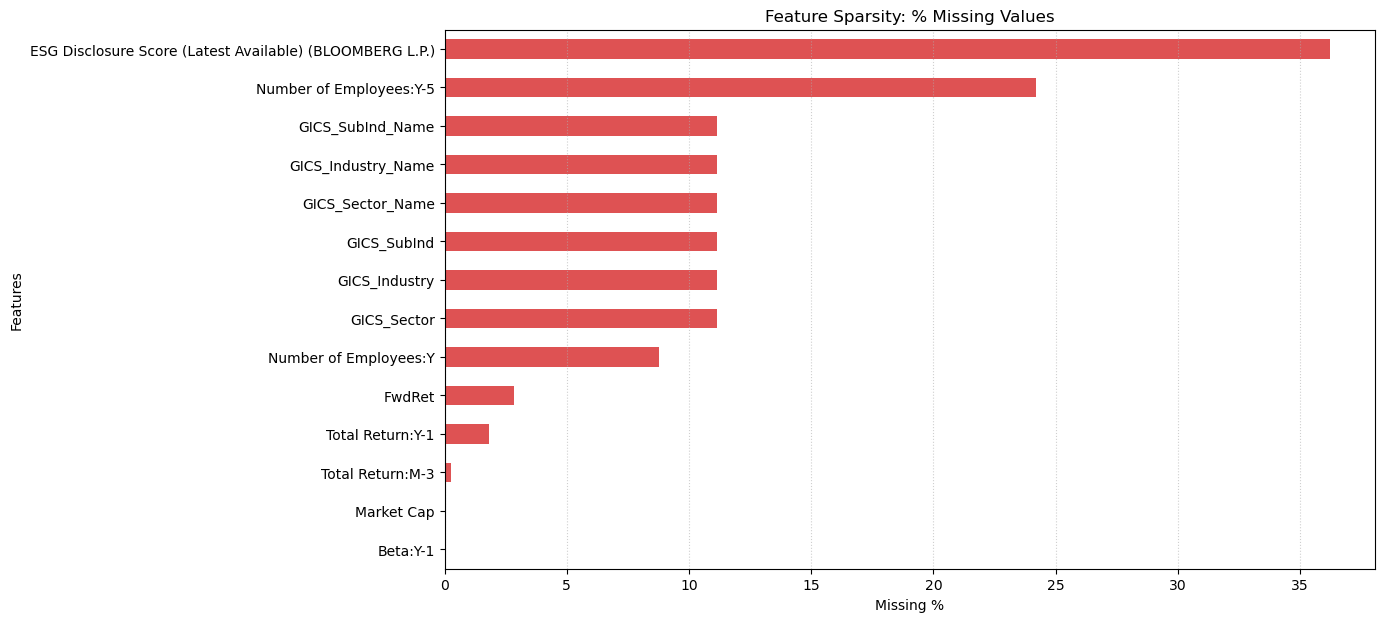

In [8]:
# Compute sparsity matrix
missing_pct = df.isnull().mean() * 100
significant_missing = missing_pct[missing_pct > 0].sort_values(ascending=True)

# Visualization of the sparsity vector
plt.figure(figsize=(12, 7))
significant_missing.plot(kind='barh', color='#d62728', alpha=0.8)
plt.title("Feature Sparsity: % Missing Values")
plt.xlabel("Missing %")
plt.ylabel("Features")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

### Target Variable Distribution
We inspect the `1D_Return_Forward` (Target) for fat tails and outliers. Extreme outliers in the target variable can destabilize gradient boosting loss functions. We clip the visualization at +/- 20% returns to inspect the central mass of the distribution.

Target Column Found: 'FwdRet'
count    166027.000000
mean          0.038304
std           0.235170
min          -0.983596
1%           -0.514156
5%           -0.294091
50%           0.029558
95%           0.378803
99%           0.730106
max          13.265487
Name: FwdRet, dtype: float64


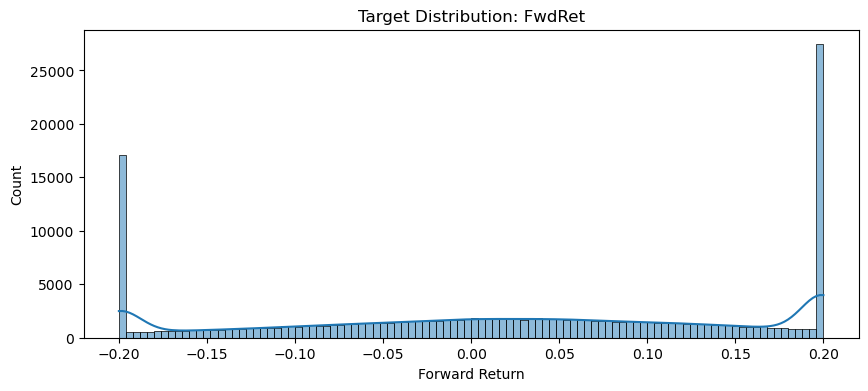

In [9]:
target_col = config['data']['target_col']

if target_col in df.columns:
    print(f"Target Column Found: '{target_col}'")
    
    # Statistical summary
    print(df[target_col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

    # Histogram
    plt.figure(figsize=(10, 4))
    sns.histplot(df[target_col].clip(lower=-0.2, upper=0.2), bins=100, kde=True, color='#1f77b4')
    plt.title(f"Target Distribution: {target_col}")
    plt.xlabel("Forward Return")
    plt.show()
else:
    print(f"ERROR: '{target_col}' is still not found in df.columns. Check spelling.")

In [ ]:
####################################################################################EOF########################################################################